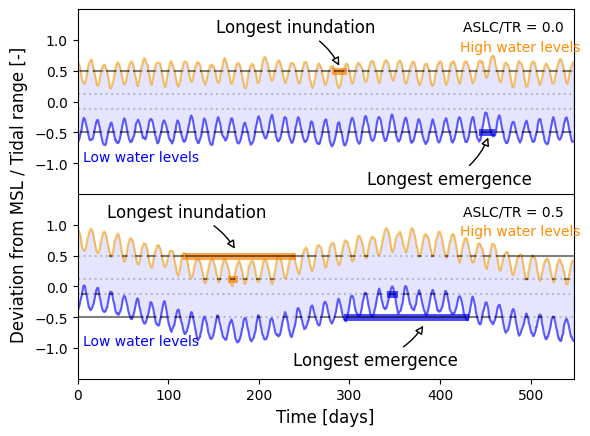

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# path_root = "/Users/timhermans/Documents/GitHub/aslc_intertidal"
path_root = "F:/collaborations/Tim_Hermans/aslc_intertidal"
os.chdir(path_root)

import src.functions as f

def figure_2a(fig, gs, path_png = None):

    def plot_timeseries(ax, amplitude_annual_cycle):

        def find_events(x):
            x = x.astype(int)
            x = np.pad(x, ((1,1)), constant_values = 0)

            # Find change points
            changes = np.diff(x)

            start = np.where(changes ==  1)[0]
            end   = np.where(changes == -1)[0]

            return start, end
        
        dt, n_years = 5/60, 1.5

        _, waterlevel, _ = f.create_waterlevel_timeseries(amplitude_annual_cycle = amplitude_annual_cycle, mean_waterlevel = 0., dt = dt, n_years = n_years)
        tidal_cycle, low_waterlevel, high_waterlevel = f.calculate_highlow_water(waterlevel, plot = False)   
        time = 365*tidal_cycle/705     
        ax.plot(time, low_waterlevel, c = 'blue', alpha = 0.6, label = 'High water level')
        ax.plot(time, high_waterlevel, c = 'orange', alpha = 0.6, label = 'Low water level')
        ax.fill_between(time, low_waterlevel, high_waterlevel, color = (0,0,1,0.1))

        for z in [-0.5,-0.12,0.12,0.5]:

            start, end = find_events(high_waterlevel < z)
            if start.size > 0:
                duration = end - start
                ax.plot([time[start[np.argmax(duration)]], time[end[np.argmax(duration)]-1]], [z, z], c = (1,0.5,0,0.7), lw = 5)
                for i in range(start.size):
                    ax.plot([time[start[i]], time[end[i]-1]], [z, z], c = (0,0,0,0.5))

            start, end = find_events(low_waterlevel > z)
            if start.size > 0:
                duration = end - start
                ax.plot([time[start[np.argmax(duration)]], time[end[np.argmax(duration)]-1]], [z, z], c = (0,0,1,0.7), lw = 5)
                for i in range(start.size):
                    ax.plot([time[start[i]], time[end[i]-1]], [z, z], c = (0,0,0,0.5))

            start, end = find_events((low_waterlevel < z) & (high_waterlevel > z))
            if start.size > 0:
                for i in range(start.size):
                    ax.plot([time[start[i]], time[end[i]-1]], [z, z], c = (0,0,0,0.2), linestyle = 'dotted')
                
        # ax.set_ylabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
        ax.set_xlabel('Time [days]', fontsize = 12)
        ax.set_yticks(ticks = [-1, -0.5, 0, 0.5, 1])
        ax.set_xlim(0, 365*1.5)
        ax.set_ylim(-1.5, 1.5)

    def add_annotations(ax0, ax1):

        #annotate longest events
        #upper half
        ann = ax0.annotate("Longest inundation",
                        xy=(0.53, 0.68), xycoords='axes fraction',
                        xytext=(0.44, 0.9), textcoords='axes fraction',
                        size=12, va="center", ha="center",
                        arrowprops=dict(arrowstyle="-|>",
                                        connectionstyle="arc3,rad=-0.2",
                                        fc="w")),
        ann = ax0.annotate("Longest emergence",
                        xy=(0.83, 0.32), xycoords='axes fraction',
                        xytext=(0.75, 0.08), textcoords='axes fraction',
                        size=12, va="center", ha="center",
                        arrowprops=dict(arrowstyle="-|>",
                                        connectionstyle="arc3,rad=0.2",
                                        fc="w")),
        ax0.text(.01,.18,'Low water levels',transform=ax0.transAxes,color='blue')
        ax0.text(.77,.775,'High water levels',transform=ax0.transAxes,color='darkorange')

        #lower half
        ann = ax1.annotate("Longest inundation",
                        xy=(0.32, 0.69), xycoords='axes fraction',
                        xytext=(0.22, 0.9), textcoords='axes fraction',
                        size=12, va="center", ha="center",
                        arrowprops=dict(arrowstyle="-|>",
                                        connectionstyle="arc3,rad=-0.2",
                                        fc="w"))
        ann = ax1.annotate("Longest emergence",
                        xy=(0.7, 0.3), xycoords='axes fraction',
                        xytext=(0.6, 0.1), textcoords='axes fraction',
                        size=12, va="center", ha="center",
                        arrowprops=dict(arrowstyle="-|>",
                                        connectionstyle="arc3,rad=0.2",
                                        fc="w"))
    
        ax1.text(.01,.18,'Low water levels',transform=ax1.transAxes,color='blue')
        ax1.text(.77,.775,'High water levels',transform=ax1.transAxes,color='darkorange')

    np.random.seed(12345)

    rows, cols = 2, 1
    gs_2a = gs.subgridspec(rows, cols, hspace = .0, wspace = .15)
    ax0 = fig.add_subplot(gs_2a[0,0])
    ax1 = fig.add_subplot(gs_2a[1,0])

    plot_timeseries(ax0, amplitude_annual_cycle = 0.0)
    ax0.set_xticks([])
    ax0.text(x = 365*1.47, y = 1.15, s = 'ASLC/TR = 0.0', horizontalalignment = 'right')
    ax0.spines['bottom'].set_visible(False)

    plot_timeseries(ax1, amplitude_annual_cycle = 0.5)
    ax1.set_ylabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
    ax1.yaxis.set_label_coords(-0.1,1)
    ax1.text(x = 365*1.47, y = 1.15, s = 'ASLC/TR = 0.5', horizontalalignment = 'right')
    # ax0.spines['top'].set_visible(False)

    add_annotations(ax0, ax1)

    if path_png is not None:
        plt.savefig(path_png, dpi = 300, bbox_inches = "tight", pad_inches = 0.2)
    plt.show()

rows, cols = 1, 1
fig = plt.figure()
gs = fig.add_gridspec(rows, cols, hspace = .1, wspace = .12) #define subplot grid
figure_2a(fig, gs[0,0])
plt.show()

In [ ]:
def figure_2a(fig, gs):

    def plot_timeseries(ax, amplitude_annual_cycle):

        def find_events(x):
            x = x.astype(int)
            x = np.pad(x, ((1,1)), constant_values = 0)

            # Find change points
            changes = np.diff(x)

            start = np.where(changes ==  1)[0]
            end   = np.where(changes == -1)[0]

            return start, end
        
        dt, n_years, sigma, rho = 5/60, 1.5, 0.013, 0.079
        elevation = np.arange(-3,3,0.01)

        _, waterlevel, _ = f.create_waterlevel_timeseries(amplitude_annual_cycle = amplitude_annual_cycle, mean_waterlevel = 0., dt = dt, n_years = n_years, sigma = sigma, rho = rho)
        tidal_cycle, low_waterlevel, high_waterlevel = f.calculate_highlow_water(waterlevel, plot = False)   
        time = 365*tidal_cycle/705     
        ax.plot(time, low_waterlevel, c = 'blue', alpha = 0.7, label = 'High water level')
        ax.plot(time, high_waterlevel, c = 'orange', alpha = 0.7, label = 'Low water level')
        ax.fill_between(time, low_waterlevel, high_waterlevel, color = (0,0,1,0.1))

        for z in [-0.5,-0.12,0.12,0.5]:

            start, end = find_events(high_waterlevel < z)
            if start.size > 0:
                duration = end - start
                ax.plot([time[start[np.argmax(duration)]], time[end[np.argmax(duration)]-1]], [z, z], c = 'orange', lw = 5, alpha=.7)
                for i in range(start.size):
                    ax.plot([time[start[i]], time[end[i]-1]], [z, z], c = (0,0,0,0.5))

            start, end = find_events(low_waterlevel > z)
            if start.size > 0:
                duration = end - start
                ax.plot([time[start[np.argmax(duration)]], time[end[np.argmax(duration)]-1]], [z, z], c = 'blue', lw = 5, alpha=.7)
                for i in range(start.size):
                    ax.plot([time[start[i]], time[end[i]-1]], [z, z], c = (0,0,0,0.5))

            start, end = find_events((low_waterlevel < z) & (high_waterlevel > z))
            if start.size > 0:
                for i in range(start.size):
                    ax.plot([time[start[i]], time[end[i]-1]], [z, z], c = (0,0,0,0.2), linestyle = 'dotted')

            if (amplitude_annual_cycle == 0) & ((z == -0.12) | (z == 0.12)):
                r = np.random.choice(time.size, size = 1)
                plt.plot([time[r],time[r+2]], [z,z], lw = 3, c = (0,0,0,0.5))

                
        # ax.set_ylabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
        ax.set_xlabel('Time [days]', fontsize = 12)
        ax.set_yticks(ticks = [-1, -0.5, 0, 0.5, 1])
        ax.set_xlim(0, 365*1.5)
        ax.set_ylim(-1.5, 1.5)

    np.random.seed(12345678)

    rows, cols = 2, 1
    gs_2a = gs.subgridspec(rows, cols, hspace = .0, wspace = .15)
    ax0 = fig.add_subplot(gs_2a[0,0])
    ax1 = fig.add_subplot(gs_2a[1,0])
    
    plot_timeseries(ax0, amplitude_annual_cycle = 0.0)
    ax0.set_xticks([])
    ax0.text(x = 365*1.47, y = 1.15, s = 'ASLC/TR = 0.0', horizontalalignment = 'right')
    ax0.spines['bottom'].set_visible(False)

    plot_timeseries(ax1, amplitude_annual_cycle = 0.5)
    ax1.set_ylabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
    ax1.yaxis.set_label_coords(-0.1,1)
    ax1.text(x = 365*1.47, y = 1.15, s = 'ASLC/TR = 0.5', horizontalalignment = 'right')
    #ax1.spines['top'].set_visible(False)

    #annotate longest events
    #upper half
    ann = ax0.annotate("Longest inundation",
                      xy=(0.17, 0.68), xycoords='axes fraction',
                      xytext=(0.26, 0.9), textcoords='axes fraction',
                      size=12, va="center", ha="center",
                      arrowprops=dict(arrowstyle="-|>",
                                     connectionstyle="arc3,rad=0.2",
                                      fc="w")),
    ann = ax0.annotate("Longest emergence",
                      xy=(0.41, 0.32), xycoords='axes fraction',
                      xytext=(0.52, 0.08), textcoords='axes fraction',
                      size=12, va="center", ha="center",
                      arrowprops=dict(arrowstyle="-|>",
                                      connectionstyle="arc3,rad=-0.2",
                                      fc="w")),
    ax0.text(.01,.18,'Low water levels',transform=ax0.transAxes,color='blue')
    ax0.text(.77,.775,'High water levels',transform=ax0.transAxes,color='darkorange')

    #lower half
    ann = ax1.annotate("Longest inundation",
                      xy=(0.32, 0.69), xycoords='axes fraction',
                      xytext=(0.18, 0.9), textcoords='axes fraction',
                      size=12, va="center", ha="center",
                      arrowprops=dict(arrowstyle="-|>",
                                      connectionstyle="arc3,rad=-0.2",
                                      fc="w"))
    ann = ax1.annotate("Longest emergence",
                      xy=(0.7, 0.3), xycoords='axes fraction',
                      xytext=(0.52, 0.1), textcoords='axes fraction',
                      size=12, va="center", ha="center",
                      arrowprops=dict(arrowstyle="-|>",
                                      connectionstyle="arc3,rad=0.2",
                                      fc="w"))
  
    ax1.text(.01,.18,'Low water levels',transform=ax1.transAxes,color='blue')
    ax1.text(.77,.775,'High water levels',transform=ax1.transAxes,color='darkorange')
